In [28]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class HARDataLoader:
    """
    Loader for the UCI Human Activity Recognition Dataset.
    
    Returns data in shape:
        (n_samples, 128, 3)
    for each sensor group.
    """

    def __init__(self, root_dir='data/raw', one_hot=False):
        """
        Args:
            root_dir (str): Path to dataset root containing train/ and test/
            one_hot (bool): Whether to return labels as one-hot vectors
        """
        self.root = Path(root_dir)
        self.one_hot = one_hot
        self.num_classes = 6

    def _load_files_in_folder(self, folder_path, prefix, dataset_type):
        """
        Load x/y/z axis files and stack into shape (samples, 128, 3).
        """
        axes = ['x', 'y', 'z']
        data = []

        for axis in axes:
            file_name = f'{prefix}_{axis}_{dataset_type}.txt'
            file_path = folder_path / file_name

            if not file_path.exists():
                raise FileNotFoundError(f"Missing expected data file: {file_path}")

            arr = pd.read_csv(file_path, sep=r'\s+', header=None).values
            data.append(arr)

        # shape: (samples, 128, 3)
        return np.stack(data, axis=-1).astype(np.float32)

    def _encode_labels(self, y_raw):
        """
        Convert labels from 1-6 to 0-5, optionally one-hot encode.
        """
        labels = y_raw.squeeze().astype(np.int64) - 1

        if self.one_hot:
            one_hot_labels = np.eye(self.num_classes, dtype=np.float32)[labels]
            return one_hot_labels

        return labels

    def get_split(self, split='train'):
        """
        Load one split of the dataset.

        Args:
            split (str): 'train' or 'test'

        Returns:
            total_accel: (n_samples, 128, 3)
            body_accel:  (n_samples, 128, 3)
            body_gyro:   (n_samples, 128, 3)
            labels:      (n_samples,) if one_hot=False
                         (n_samples, 6) if one_hot=True
        """
        split_dir = self.root / split
        signal_dir = split_dir / 'Inertial Signals'

        total_accel = self._load_files_in_folder(signal_dir, 'total_acc', split)
        body_accel  = self._load_files_in_folder(signal_dir, 'body_acc', split)
        body_gyro   = self._load_files_in_folder(signal_dir, 'body_gyro', split)

        label_file = split_dir / f'y_{split}.txt'
        if not label_file.exists():
            raise FileNotFoundError(f"Missing label file: {label_file}")

        y_raw = pd.read_csv(label_file, sep=r'\s+', header=None).values
        labels = self._encode_labels(y_raw)

        return total_accel, body_accel, body_gyro, labels

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, class_names, title="Confusion Matrix", normalize=False):
    cm = np.array(cm, dtype=float)

    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        cm = np.divide(cm, row_sums, where=row_sums != 0)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")

    # title and axis labels
    ax.set_title(title, fontsize=14, pad=12, weight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    # ticks
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=30, ha="right", fontsize=10)
    ax.set_yticklabels(class_names, fontsize=10)

    # colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=10)

    # grid-like cell borders
    ax.set_xticks(np.arange(cm.shape[1] + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(cm.shape[0] + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)

    # annotate cells
    threshold = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            text = f"{value:.2f}" if normalize else f"{int(value)}"
            ax.text(
                j, i, text,
                ha="center", va="center",
                color="white" if value > threshold else "black",
                fontsize=11, fontweight="bold"
            )

    plt.tight_layout()
    plt.show()

In [30]:
loader = HARDataLoader('../data/raw', one_hot=False)
train_total_accel, train_body_accel, train_body_gyro, train_labels = loader.get_split('train')
test_total_accel, test_body_accel, test_body_gyro, test_labels = loader.get_split('test')

In [31]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Flatten each modality
X_train_total = train_total_accel.reshape(train_total_accel.shape[0], -1)
X_train_bodya = train_body_accel.reshape(train_body_accel.shape[0], -1)
X_train_gyro  = train_body_gyro.reshape(train_body_gyro.shape[0], -1)

X_test_total = test_total_accel.reshape(test_total_accel.shape[0], -1)
X_test_bodya = test_body_accel.reshape(test_body_accel.shape[0], -1)
X_test_gyro  = test_body_gyro.reshape(test_body_gyro.shape[0], -1)

# Concatenate all features
X_train = np.concatenate([X_train_total, X_train_bodya, X_train_gyro], axis=1)
X_test  = np.concatenate([X_test_total, X_test_bodya, X_test_gyro], axis=1)

# Labels
y_train = np.array(train_labels).ravel()
y_test  = np.array(test_labels).ravel()

# Train RF
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

Test Accuracy: 0.8463

Classification Report:
              precision    recall  f1-score   support

     Walking       0.81      0.87      0.83       496
    Upstairs       0.83      0.79      0.81       471
  Downstairs       0.84      0.87      0.85       420
     Sitting       0.76      0.79      0.77       491
    Standing       0.84      0.76      0.79       532
      Laying       1.00      1.00      1.00       537

    accuracy                           0.85      2947
   macro avg       0.84      0.85      0.84      2947
weighted avg       0.85      0.85      0.85      2947

Confusion Matrix:
[[430  22  44   0   0   0]
 [ 71 373  27   0   0   0]
 [ 29  25 366   0   0   0]
 [  2  24   0 386  79   0]
 [  2   4   0 124 402   0]
 [  0   0   0   0   0 537]]


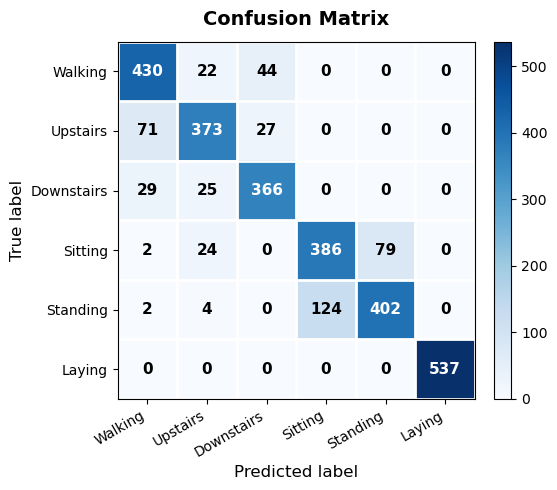

In [33]:
# Evaluate
class_names = ["Walking", "Upstairs", "Downstairs", "Sitting", "Standing", "Laying"]
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)
plot_confusion_matrix(cm, class_names, title="Confusion Matrix")